In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [80]:

# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION: set your paths here
# ────────────────────────────────────────────────────────────────────────────────
FILE_PATH   = './_data/mwb_may_july_25.csv'   # ← update this
OUTPUT_PATH = './_data/output.csv'

# ────────────────────────────────────────────────────────────────────────────────
# 1. User-defined mapping: substrings → category labels
# ────────────────────────────────────────────────────────────────────────────────
CATEGORY_MAP = {
    "STARBUCKS":     "Coffee",
    "VISHWA SHANTI CAFE": "Coffee",
    "WAL-MART":       "Groceries",
    "WM SUPERCENTER":         "Groceries",
    "HAWKEYE":         "Smoke",
    "CASH APP":         "Transfer",
    "MARSHALLS":       "Shopping",
    "ALMOST PARADISE":       "Smoke",
    "WITHDRAWAL":      "Cash Withdrawal",
    # … add more mappings here …
}

# ────────────────────────────────────────────────────────────────────────────────
# 2. Categorization helper
# ────────────────────────────────────────────────────────────────────────────────
def categorize(txn_str: str, mapping: dict, default="Other") -> str:
    text = txn_str.upper()
    for substr, category in mapping.items():
        if substr.upper() in text:
            return category
    return default

# ────────────────────────────────────────────────────────────────────────────────
# 3. ETL & Summary
# ────────────────────────────────────────────────────────────────────────────────
def analyze_bank_csv(path: str, mapping: dict):
    # 1) Load CSV and parse dates
    df = pd.read_csv(path, parse_dates=["Date"])

    # 2) Build search field from Description only
    df["_search"] = df["Description"].fillna("")

    # 3a) Categorize based on Description
    df["Category"] = df["_search"].apply(lambda s: categorize(s, mapping))

    # 3b) Clean up Amount → numeric float
    #    strip $ and commas, convert to float
    amt = (
        df["Amount"]
          .str.replace(r"[\$,]", "", regex=True)  # remove currency chars
          .astype(float)                          # parse to float
    )

    # 3c) Debit/Credit columns
    #    positive amounts → Credit; negative → Debit (made positive)
    df["Credit"] = amt.clip(lower=0)
    df["Debit"]  = (-amt).clip(lower=0)

    # 4a) Summaries
    total_credit = df["Credit"].sum()
    total_debit  = df["Debit"].sum()

    # 4b) Breakdown of debits by category
    debit_by_cat = (
        df[df["Debit"] > 0]
          .groupby("Category")["Debit"]
          .sum()
          .sort_values(ascending=False)
    )

    # display intermediate if you like:
    display(df[["Date","Description","Amount","Credit","Debit","Category"]].head())

    # 6) Now you can group by Cost instead of Amount
    summary = (
        df[df["Debit"] > 0]             # expenses only (Cost > 0)
          .groupby("Category")["Debit"]
          .sum()
          .sort_values(ascending=False)
    )
    
    res = { "total_credit": total_credit,
        "total_debit": total_debit,
        "debit_by_category": debit_by_cat }

    return df, summary, res

# ────────────────────────────────────────────────────────────────────────────────
# 4. Plotting
# ────────────────────────────────────────────────────────────────────────────────
def plot_summary(summary: pd.Series):
    plt.figure()
    plt.bar(summary.index, summary.values)
    plt.xlabel('Category')
    plt.ylabel('Total Spend')
    plt.title('Spend by Category')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.figure()
    plt.pie(summary.values, labels=summary.index, autopct='%1.1f%%')
    plt.title('Spend Distribution by Category')
    plt.tight_layout()

    plt.show()

# ────────────────────────────────────────────────────────────────────────────────
# 5. Main
# ────────────────────────────────────────────────────────────────────────────────
def main():
    # 5a) Run analysis
    df_cat, spend_summary, res = analyze_bank_csv(FILE_PATH, CATEGORY_MAP)
    display(spend_summary)
    print(f"\nTotal Credit: ${res['total_credit']:.2f}")
    print(f"Total Debit: ${res['total_debit']:.2f}")

    # 5b) Print text summary
    print("\n=== Spend by Category ===")
    print(spend_summary.to_string())

    # 5c) Optionally write full annotated CSV
    if OUTPUT_PATH:
        df_cat.drop(columns=["_search"]).to_csv(OUTPUT_PATH, index=False)
        print(f"\nCategorized transactions written to: {OUTPUT_PATH}")

    # 5d) Show graphs
    plot_summary(spend_summary)

,Date,Description,Amount,Credit,Debit,Category
0,2025-08-01,758350 DDA PURCHASE SQ *VISHWA SHANTI CAFE Fai...,-$1.50,0.0,1.50,Coffee
1,2025-08-01,XX7023 DDA POS BP#2689000UNIVE FAIRFIELD IA 08...,-$10.71,0.0,10.71,Other
2,2025-08-01,XX7023 DDA PURCHASE SQ *VISHWA SHANTI CAFE Fai...,-$5.75,0.0,5.75,Coffee
3,2025-08-01,XX7023 DDA PURCHASE SQ *VISHWA SHANTI CAFE Fai...,-$4.00,0.0,4.00,Coffee
4,2025-08-01,MAHARISHI INTERN PAYROLL 260102127917L6I,$58.00,58.0,0.00,Other


Category
Groceries          427.92
Cash Withdrawal    425.00
Other              386.52
Smoke              353.67
Transfer           343.00
Coffee             266.85
Shopping           161.02
Name: Debit, dtype: float64


Total Credit: $9758.00
Total Debit: $2363.98

=== Spend by Category ===
Category
Groceries          427.92
Cash Withdrawal    425.00
Other              386.52
Smoke              353.67
Transfer           343.00
Coffee             266.85
Shopping           161.02

Categorized transactions written to: ./_data/output.csv


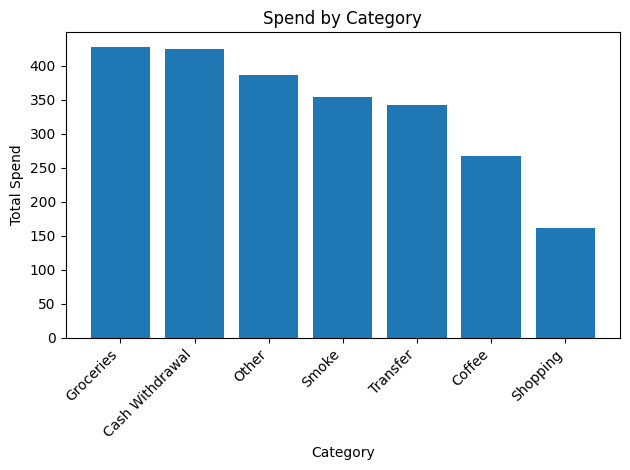

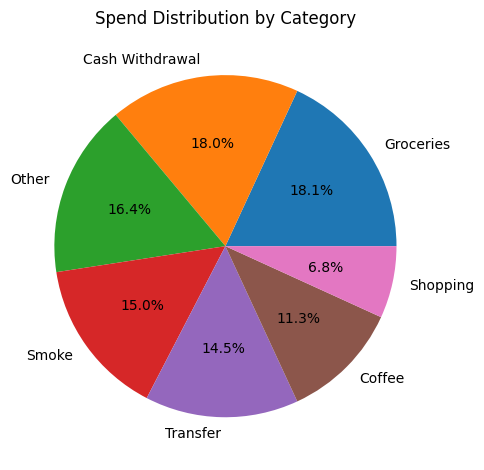

In [81]:
# Main entry point
main()